<div style="width: 100%; margin-bottom: 20px;">
    <img src="../assets/banner.png" style="width: 100%; border-radius: 10px; height: 300px; object-fit: cover;">
</div>

# Phase 3 : Tuning des hyperparametres
## Projet ML : Prediction des Tempetes Geomagnetiques

**Realise par :**
- AMEZIANE Oumaima
- ROHAND Douae
- MOHITO Raihana

**Date :** 2025-2026  
**Cours :** Machine Learning - 2eme annee Cycle Ingenieurs GI  
**Encadrant :** Pr. Y. EL YOUNOUSSI

---

Ce notebook correspond a la **2eme partie de la Phase 3** du projet AURORAS.

A partir de la meilleure combinaison identifiee dans `04_modeling.ipynb` ,
nous optimisons les hyperparametres du modele retenu via `GridSearchCV` ou `RandomizedSearchCV`
selon la taille de l'espace de recherche.

**Regles absolues respectees dans ce notebook :**
- Le tuning se fait uniquement sur le jeu d'entrainement avec validation croisee stratifiee.
- Les plages de recherche sont toutes justifiees par des arguments algorithmiques ou metier.

## Objectifs :
1. Charger la meilleure combinaison produite par `04_modeling.ipynb`.
2. Reconstruire le pipeline correspondant.
3. Definir et justifier la grille d'hyperparametres adaptee au modele gagnant.
4. Lancer l'optimisation (GridSearchCV ou RandomizedSearchCV selon la taille de l'espace).
5. Analyser et interpreter les resultats du tuning.
6. Serialiser le pipeline final dans `models/final_model.joblib`.


## Etape 1 : Imports et chargement des donnees

On importe toutes les librairies en haut du notebook.
On recharge le meme jeu d'entrainement fusionne (train + validation) que celui
utilise dans `04_modeling.ipynb`, afin de garantir la coherence des resultats.
Le jeu de test reste intouche.


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

# XGBoost
from xgboost import XGBClassifier

# imblearn — pipeline OBLIGATOIRE pour eviter le data leakage avec SMOTE/Undersampling
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

pd.set_option('display.max_columns', None)

# 1. Chargement du preprocessor (Phase 2)

preprocessor = joblib.load('../models/preprocessor.joblib')
print("Preprocessor charge avec succes.")


# 2. Chargement et fusion train + validation (identique a 04_modeling.ipynb)
# Le test set reste intouche jusqu'a 06_evaluation.ipynb

TARGET = 'is_storm'

df_train = pd.read_csv('../data/processed/train.csv')
df_val   = pd.read_csv('../data/processed/validation.csv')
df_all   = pd.concat([df_train, df_val], ignore_index=True)

X_train = df_all.drop(columns=[TARGET])
y_train = df_all[TARGET]

# Ratio pour scale_pos_weight XGBoost
scale_pos_w = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Taille du jeu d'entrainement fusionne : {X_train.shape}")
print(f"Distribution de la cible :\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"scale_pos_weight XGBoost : {scale_pos_w:.2f}")


Preprocessor charge avec succes.
Taille du jeu d'entrainement fusionne : (36725, 24)
Distribution de la cible :
is_storm
0    91.59
1     8.41
Name: proportion, dtype: float64
scale_pos_weight XGBoost : 10.89


### Interpretation : Chargement des donnees

Le jeu d'entrainement fusionne contient **36 725 observations** et **24 features**, ce qui represente un volume suffisant pour un tuning fiable par validation croisee.

La distribution de la cible revele un **fort desequilibre de classes** : seulement 8,41 % des observations correspondent a une tempete (classe 1), contre 91,59 % de non-tempetes (classe 0). Ce ratio de ~1:11 justifie pleinement l'utilisation de strategies de reequilibrage (Undersampling, SMOTE, class_weight).

Le parametre  est calcule comme le rapport exact entre les effectifs (classe 0 / classe 1). Il sera utilise si XGBoost est le modele gagnant pour compenser ce desequilibre sans rééchantillonnage physique.

## Etape 2 : Chargement de la meilleure combinaison 

On lit le fichier CSV produit par `04_modeling.ipynb`.
Ce fichier est trie par Recall decroissant, donc la premiere ligne est la gagnante.
Ce chargement est correct car il garantit que le choix du modele a tuner
est base sur les resultats de la validation croisee complete a 5 folds,
et non sur une intuition subjective. Le tri par Recall est coherent avec
l'objectif metier : une tempete geomagnetique non detectee est plus
couteuse qu'une fausse alarme.


In [2]:
# Chargement des resultats
results_df = pd.read_csv('../data/processed/modeling_results.csv')


display(results_df.round(4))

# Meilleure combinaison = premiere ligne du tableau trie
best = results_df.iloc[0]


print("  MEILLEURE COMBINAISON IDENTIFIEE DANS LE MODELING")

print(f"  Modele              : {best['Model']}")
print(f"  Reeequilibrage      : {best['Balancing_Strategy']}")
print(f"  Recall moyen (CV)   : {best['Recall_Mean']:.4f} +/- {best['Recall_Std']:.4f}")
print(f"  F1 moyen (CV)       : {best['F1_Mean']:.4f} +/- {best['F1_Std']:.4f}")
print(f"  Precision moyenne   : {best['Precision_Mean']:.4f}")
print(f"  ROC-AUC moyen       : {best['ROC_AUC_Mean']:.4f}")


best_model_name    = best['Model']
best_strategy_name = best['Balancing_Strategy']


,Model,Balancing_Strategy,Recall_Mean,Recall_Std,F1_Mean,F1_Std,Precision_Mean,ROC_AUC_Mean
0,Random_Forest,Undersampling,0.9171,0.0078,0.5257,0.0042,0.3685,0.9549
1,XGBoost,Undersampling,0.9013,0.0140,0.5237,0.0118,0.3692,0.9493
2,Decision_Tree,Undersampling,0.8252,0.0189,0.4461,0.0232,0.3058,0.8262
3,XGBoost,No_Resampling_ClassWeight,0.7996,0.0095,0.6629,0.0120,0.5663,0.9616
4,Logistic_Regression,SMOTE,0.7799,0.0120,0.3937,0.0041,0.2633,0.8679
5,Logistic_Regression,No_Resampling_ClassWeight,0.7795,0.0156,0.3924,0.0033,0.2622,0.8685
6,Logistic_Regression,Undersampling,0.7792,0.0130,0.3909,0.0046,0.2609,0.8680
7,Random_Forest,SMOTE,0.7294,0.0147,0.7518,0.0160,0.7757,0.9740
8,Decision_Tree,SMOTE,0.6779,0.0205,0.6099,0.0144,0.5545,0.8139
9,XGBoost,SMOTE,0.6089,0.0085,0.6606,0.0097,0.7221,0.9557


  MEILLEURE COMBINAISON IDENTIFIEE DANS LE MODELING
  Modele              : Random_Forest
  Reeequilibrage      : Undersampling
  Recall moyen (CV)   : 0.9171 +/- 0.0078
  F1 moyen (CV)       : 0.5257 +/- 0.0042
  Precision moyenne   : 0.3685
  ROC-AUC moyen       : 0.9549


### Interpretation : Resultats du modeling et choix du modele a tuner

Le tableau presente les 12 combinaisons (modele x strategie de reequilibrage) evaluees lors de l'etape de modeling, triees par **Recall decroissant**. Le choix du Recall comme critere principal est justifie par l'objectif metier : manquer une tempete geomagnetique reelle est plus couteux qu'une fausse alarme.

**La combinaison gagnante est Random Forest + Undersampling** avec un Recall moyen de **0.9171** (± 0.0078). Cela signifie que, en validation croisee, le modele detecte correctement 91,7 % des tempetes.

Quelques observations importantes :
- Le Recall eleve (0.9171) s'accompagne d'une precision relativement faible (0.3685), ce qui est attendu avec l'Undersampling : on accepte plus de fausses alarmes pour ne pas manquer les vraies tempetes.
- Le ROC-AUC de 0.9549 confirme que le modele distingue bien les deux classes au niveau du ranking, independamment du seuil de classification.
- L'ecart-type faible (0.0078) indique une bonne stabilite du modele entre les 5 folds de la cross-validation.

## Etape 3 : Reconstruction du pipeline de base

On reconstruit le pipeline de la meilleure combinaison, avec les memes
parametres de base que dans `04_modeling.ipynb`, avant d'y appliquer le tuning.

Le pipeline suit systematiquement la structure :
`preprocessor -> (resampler si applicable) -> modele`


Repartir d'un clone propre evite tout risque de contamination par
des etats internes residuels d'une execution precedente.
L'utilisation d'`ImbPipeline` (imblearn) et non de `Pipeline` (sklearn)
est obligatoire quand un resampler est present, pour que SMOTE ou
Undersampling ne s'appliquent qu'aux folds d'entrainement et jamais
aux folds de validation lors de la cross-validation.


In [3]:
def build_base_model(model_name, strategy_name, scale_pos_w):
    """
    Reconstruit le modele de base (parametres par defaut) correspondant
    a la combinaison gagnante identifiee par la l'etape de modeling.
    """
    # --- Definition du modele ---
    if model_name == 'Logistic_Regression':
        model = LogisticRegression(random_state=42, max_iter=1000)
    elif model_name == 'Decision_Tree':
        model = DecisionTreeClassifier(random_state=42)
    elif model_name == 'Random_Forest':
        model = RandomForestClassifier(random_state=42, n_jobs=-1)
    elif model_name == 'XGBoost':
        model = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
    else:
        raise ValueError(f"Modele inconnu : {model_name}")

    # --- Ajustement des poids (strategie class_weight uniquement) ---
    if strategy_name == 'No_Resampling_ClassWeight':
        if model_name == 'XGBoost':
            model.set_params(scale_pos_weight=scale_pos_w)
        elif model_name == 'Random_Forest':
            model.set_params(class_weight='balanced_subsample')
        else:
            model.set_params(class_weight='balanced')
    else:
        if model_name == 'XGBoost':
            model.set_params(scale_pos_weight=1)
        else:
            if model_name not in ['XGBoost']:
                try:
                    model.set_params(class_weight=None)
                except Exception:
                    pass

    # --- Construction du pipeline ---
    if strategy_name == 'No_Resampling_ClassWeight':
        pipeline = ImbPipeline([
            ('preprocessor', clone(preprocessor)),
            ('clf', model)
        ])
    elif strategy_name == 'SMOTE':
        pipeline = ImbPipeline([
            ('preprocessor', clone(preprocessor)),
            ('resampler',    SMOTE(random_state=42)),
            ('clf',          model)
        ])
    elif strategy_name == 'Undersampling':
        pipeline = ImbPipeline([
            ('preprocessor', clone(preprocessor)),
            ('resampler',    RandomUnderSampler(random_state=42)),
            ('clf',          model)
        ])
    else:
        raise ValueError(f"Strategie inconnue : {strategy_name}")

    return pipeline


base_pipeline = build_base_model(best_model_name, best_strategy_name, scale_pos_w)
print(f"Pipeline de base reconstruit : {best_model_name} + {best_strategy_name}")
print(base_pipeline)


Pipeline de base reconstruit : Random_Forest + Undersampling
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['solar_wind_speed',
                                                   'solar_wind_density',
                                                   'bz_component',
                                                   'solar_wind_pressure',
                                                   'bz_min_3h', 'dst_index',
                                                   'bz_dst_interaction',
                                                   'dst_rate_change']),
                                                 ('passthrough', 'passthrough',
                                                  ['sin_month', 'cos_month',
                                                   'bz_negative',
                                                   'is_solar_maximum',
                                

### Interpretation : Pipeline reconstruit

Le pipeline affiche confirme la structure correcte : **preprocesseur → resampler → classifieur**.

NB :
- Le **RobustScaler** est applique aux variables numeriques continues (vitesse du vent solaire, composante Bz, pression, etc.), ce qui le rend robuste aux valeurs aberrantes frequentes dans les donnees spatiales.
- Les variables binaires et cycliques (saisons, intervalles horaires, indicateurs booleen) sont passees telles quelles via , ce qui est correct car elles n'ont pas besoin de normalisation.
- Le **RandomUnderSampler** est integre dans le pipeline ImbPipeline (et non sklearn Pipeline) : cela garantit que le reequilibrage ne s'applique qu'aux folds d'entrainement lors de la cross-validation, evitant ainsi toute fuite de donnees (data leakage) vers les folds de validation.

## Etape 4 : Definition et justification de la grille d'hyperparametres

La grille est adaptee automatiquement au modele gagnant.
Chaque plage testee est accompagnee d'une justification explicite.
Une grille mal choisie est aussi penalisante qu'une absence de tuning
(cf. consignes Phase 3).

**Principe de choix entre GridSearchCV et RandomizedSearchCV :**
- Si le nombre total de combinaisons est inferieur ou egal a 50 : `GridSearchCV` (exhaustif).
- Si le nombre total de combinaisons depasse 50 : `RandomizedSearchCV` avec `n_iter=40`
  pour explorer efficacement un grand espace sans le parcourir entierement.


In [4]:
import math

def get_param_grid(model_name, strategy_name, scale_pos_w):
    """
    Retourne la grille d'hyperparametres justifiee pour le modele donne.
    Toutes les cles utilisent le prefixe 'clf__' car le modele
    se nomme 'clf' dans le pipeline ImbPipeline.
    """

    if model_name == 'Logistic_Regression':
        # C controle la force de regularisation : 1/C.
        # Valeurs testees : 0.01 a 10 sur une echelle logarithmique.
        # En dessous de 0.01 : regularisation trop forte, underfitting.
        # Au dessus de 10 : regularisation quasi nulle, risque d'overfitting.
        # penalty : 'l2' (Ridge) est le defaut robuste ; 'l1' (Lasso) permet
        #           la selection de variables, utile si beaucoup de features peu informatives.
        # solver 'saga' supporte l1 et l2 et passe bien a l'echelle.
        param_grid = {
            'clf__C':       [0.01, 0.1, 1, 10],
            'clf__penalty': ['l1', 'l2'],
            'clf__solver':  ['saga'],
        }
        print("Justification des plages — Logistic Regression :")
        print("  clf__C       : [0.01, 0.1, 1, 10]  -> echelle log, couvre sous-regularise a sur-regularise")
        print("  clf__penalty : ['l1', 'l2']          -> l1 pour selection de variables, l2 pour stabilite")
        print("  clf__solver  : ['saga']               -> seul solver supportant l1 ET l2 avec grands datasets")

    elif model_name == 'Decision_Tree':
        # max_depth : valeurs entre 3 et 15.
        # En dessous de 3 : arbre trop superficiel, underfitting.
        # Au dessus de 15 : memorisation quasi totale, overfitting severe.
        # min_samples_leaf : nombre minimal d'exemples dans une feuille.
        # Augmenter cette valeur regularise l'arbre en evitant les feuilles pures sur 1 seul exemple.
        param_grid = {
            'clf__max_depth':        [3, 5, 7, 10, 15],
            'clf__min_samples_leaf': [1, 5, 10, 20],
            'clf__min_samples_split':[2, 10, 20],
        }
        print("Justification des plages — Decision Tree :")
        print("  clf__max_depth        : [3,5,7,10,15]  -> borne inf=3 (trop simple), borne sup=15 (overfitting)")
        print("  clf__min_samples_leaf : [1,5,10,20]    -> 1=arbre profond, 20=arbre fortement regularise")
        print("  clf__min_samples_split: [2,10,20]      -> controle la subdivision des noeuds internes")

    elif model_name == 'Random_Forest':
        # n_estimators : nombre d'arbres. 200 est le minimum raisonnable.
        # Au dela de 500, le gain marginal devient negligeable mais le temps de calcul augmente.
        # max_depth=None signifie arbres complets (pas de troncature) ; les autres valeurs
        # regularisent explicitement.
        # min_samples_leaf : meme logique que pour l'arbre de decision.
        # max_features='sqrt' est quasi-optimal pour la classification (recommandation Breiman).
        param_grid = {
            'clf__n_estimators':     [200, 500],
            'clf__max_depth':        [10, 20, None],
            'clf__min_samples_leaf': [1, 2, 5],
            'clf__max_features':     ['sqrt'],
        }
        print("Justification des plages — Random Forest :")
        print("  clf__n_estimators     : [200, 500]      -> 200=minimum viable, 500=rendement decroissant apres")
        print("  clf__max_depth        : [10, 20, None]  -> None=arbres complets, 10/20=regularisation explicite")
        print("  clf__min_samples_leaf : [1, 2, 5]       -> regularisation des feuilles")
        print("  clf__max_features     : ['sqrt']        -> valeur reference Breiman pour la classification")

    elif model_name == 'XGBoost':
        # max_depth : entre 3 et 7.
        # En dessous de 3 : interactions entre variables impossibles a capturer.
        # Au dessus de 7 : overfitting tres probable sur donnees tabulaires.
        # learning_rate : entre 0.01 et 0.1.
        # 0.01 = apprentissage lent et stable, necessite plus d'estimateurs.
        # 0.1 = apprentissage rapide, risque d'overshooting.
        # n_estimators : entre 300 et 1000.
        # Avec un learning_rate faible, il faut davantage d'arbres pour converger.
        # subsample et colsample_bytree : entre 0.7 et 1.0.
        # Sous-echantillonnage des lignes et des colonnes a chaque arbre.
        # Valeurs inferieures a 0.7 degradent generalement les performances.
        # scale_pos_weight : calcule exactement comme ratio classe 0 / classe 1.
        # Compense le desequilibre en penalisant davantage les erreurs sur la minorite.
        param_grid = {
            'clf__max_depth':         [3, 5, 7],
            'clf__learning_rate':     [0.01, 0.05, 0.1],
            'clf__n_estimators':      [300, 500, 800],
            'clf__subsample':         [0.7, 0.85, 1.0],
            'clf__colsample_bytree':  [0.7, 0.85, 1.0],
        }
        # Pour la strategie class_weight (scale_pos_weight), on fixe le parametre
        # dans le pipeline et on ne le met pas dans la grille car sa valeur
        # est determinee mathematiquement par le ratio des classes.
        print("Justification des plages — XGBoost :")
        print("  clf__max_depth        : [3, 5, 7]           -> < 3 : underfitting, > 7 : overfitting tabulaire")
        print("  clf__learning_rate    : [0.01, 0.05, 0.1]   -> echelle log, de stable a rapide")
        print("  clf__n_estimators     : [300, 500, 800]      -> plus d'arbres compense un faible learning_rate")
        print("  clf__subsample        : [0.7, 0.85, 1.0]    -> sous-echantillonnage lignes, < 0.7 degrade")
        print("  clf__colsample_bytree : [0.7, 0.85, 1.0]    -> sous-echantillonnage features, meme logique")

    else:
        raise ValueError(f"Modele non supporte pour le tuning : {model_name}")

    # Calcul du nombre total de combinaisons
    n_combos = math.prod(len(v) for v in param_grid.values())
    print(f"\nNombre total de combinaisons : {n_combos}")

    return param_grid, n_combos


param_grid, n_combos = get_param_grid(best_model_name, best_strategy_name, scale_pos_w)


Justification des plages — Random Forest :
  clf__n_estimators     : [200, 500]      -> 200=minimum viable, 500=rendement decroissant apres
  clf__max_depth        : [10, 20, None]  -> None=arbres complets, 10/20=regularisation explicite
  clf__min_samples_leaf : [1, 2, 5]       -> regularisation des feuilles
  clf__max_features     : ['sqrt']        -> valeur reference Breiman pour la classification

Nombre total de combinaisons : 18


### Interpretation : Grille d'hyperparametres

La grille definie pour Random Forest couvre **18 combinaisons** (2 × 3 × 3 × 1), ce qui est inferieur au seuil de 50 : on utilisera donc un **GridSearchCV exhaustif** a l'etape suivante.

Analyse des choix de plages :
- **n_estimators [200, 500]** : 200 arbres est le minimum pour avoir une foret stable ; au-dela de 500, le gain en performance est marginal tandis que le temps de calcul augmente lineairement.
- **max_depth [10, 20, None]** :  laisse les arbres croitre jusqu'a la purete totale (risque de sur-apprentissage) ; 10 et 20 imposent une regularisation explicite de la profondeur.
- **min_samples_leaf [1, 2, 5]** : controle la taille minimale des feuilles terminales. Des valeurs plus elevees regularisent davantage en empechant la creation de feuilles sur un seul exemple.
- **max_features = 'sqrt'** : valeur recommandee par Breiman (createur des Random Forests) pour la classification ; seule cette valeur est testee car elle est quasi-optimale pour ce type de probleme.

## Etape 5 : Lancement de l'optimisation des hyperparametres

Le choix entre `GridSearchCV` et `RandomizedSearchCV` est fait automatiquement
selon le nombre de combinaisons calcule a l'etape precedente.

**Rappel des contraintes :**
- La cross-validation interne utilise `StratifiedKFold(n_splits=5)` pour preserver
  le ratio de desequilibre dans chaque fold.
- La metrique de scoring est le **Recall**, coherente avec l'objectif metier
  (minimiser les tempetes non detectees).
- Le jeu de test n'est pas touche.

**Interpretation du choix de la methode :**
- `GridSearchCV` sur un espace de 50 combinaisons ou moins : correct, le temps
  de calcul reste maitrise et l'exploration est exhaustive.
- `RandomizedSearchCV` avec `n_iter=40` sur un grand espace : correct. Avec 40
  tirages aleatoires sur des centaines de combinaisons possibles, on couvre
  l'espace de maniere statistiquement representative sans le parcourir entierement.
  Le gain de temps est considerable (facteur 5 a 10) pour une perte de qualite
  generalement negligeable.


In [5]:
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

SEUIL_GRID = 50  # Au-dela de ce nombre, on passe a RandomizedSearchCV

if n_combos <= SEUIL_GRID:
    methode = "GridSearchCV"
    search = GridSearchCV(
        estimator  = base_pipeline,
        param_grid = param_grid,
        scoring    = 'recall',
        cv         = cv_inner,
        n_jobs     = -1,
        verbose    = 2,
        refit      = True,
        return_train_score = True,
    )
    print(f"GridSearchCV selectionne : {n_combos} combinaisons (<= {SEUIL_GRID}).")
else:
    methode = "RandomizedSearchCV"
    N_ITER = 40
    search = RandomizedSearchCV(
        estimator            = base_pipeline,
        param_distributions  = param_grid,
        n_iter               = N_ITER,
        scoring              = 'recall',
        cv                   = cv_inner,
        n_jobs               = -1,
        verbose              = 2,
        refit                = True,
        random_state         = 42,
        return_train_score   = True,
    )
    print(f"RandomizedSearchCV selectionne : {n_combos} combinaisons > {SEUIL_GRID}, n_iter=40.")

print(f"\nLancement du {methode} sur {X_train.shape[0]} exemples...")
print("Patience, cela peut prendre plusieurs minutes selon la machine.\n")

search.fit(X_train, y_train)

print("\nOptimisation terminee.")
print(f"Meilleur Recall (CV) : {search.best_score_:.4f}")
print(f"Meilleurs parametres : {search.best_params_}")


GridSearchCV selectionne : 18 combinaisons (<= 50).

Lancement du GridSearchCV sur 36725 exemples...
Patience, cela peut prendre plusieurs minutes selon la machine.

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Optimisation terminee.
Meilleur Recall (CV) : 0.9217
Meilleurs parametres : {'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 500}


### Interpretation : Resultats de l'optimisation

Le **GridSearchCV exhaustif** a teste les 18 combinaisons avec 5 folds chacune (90 fits au total) sur 36 725 exemples.

**Le meilleur Recall obtenu en CV est de 0.9217**, avec les hyperparametres optimaux : , , , .

Ce resultat signifie que la combinaison optimale utilise les arbres les plus profonds (max_depth=20) et les plus nombreux (500 estimateurs) avec des feuilles unitaires (min_samples_leaf=1), ce qui suggere que le modele beneficie d'une capacite d'apprentissage elevee sur ce dataset. L'absence de troncature severe est coherente avec un dataset de taille suffisante (36k exemples).

## Etape 6 : Analyse des resultats du tuning

On examine en detail les resultats de la recherche pour comprendre
quels hyperparametres ont le plus d'impact et si le tuning a reellement
ameliore les performances par rapport au modele de base.

**Interpretation (bonne pratique) :**
Un tuning est considere comme reussi si le Recall (CV) du meilleur modele
tune est superieur au Recall (CV) du modele de base rapporte par la l'etape de modeling.
Si la difference est inferieure a 0.01, l'amelioration est marginale et le
modele de base avec ses hyperparametres par defaut etait deja bien configure.


In [6]:
# ---------------------------------------------------------
# Tableau des N meilleures configurations
# ---------------------------------------------------------
cv_results = pd.DataFrame(search.cv_results_)

# Colonnes pertinentes
cols_affichees = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
] + [c for c in cv_results.columns if c.startswith('param_')]

top_n = cv_results[cols_affichees].sort_values('rank_test_score').head(15)
top_n.columns = [c.replace('param_clf__', '').replace('mean_test_score', 'Recall_CV_mean')
                  .replace('std_test_score', 'Recall_CV_std')
                  .replace('mean_train_score', 'Recall_train_mean')
                  .replace('rank_test_score', 'Rang')
                  for c in top_n.columns]

print("Top 15 configurations :")
display(top_n.round(4))

# ---------------------------------------------------------
# Comparaison tuning vs baseline (baseline modeling)
# ---------------------------------------------------------
recall_baseline = best['Recall_Mean']
recall_tune     = search.best_score_
gain            = recall_tune - recall_baseline

print("\n" + "=" * 60)
print("  COMPARAISON : BASELINE vs MODELE TUNE")
print("=" * 60)
print(f"  Recall baseline (baseline modeling) : {recall_baseline:.4f}")
print(f"  Recall apres tuning          : {recall_tune:.4f}")
print(f"  Gain                         : {gain:+.4f}")

if gain > 0.01:
    print("  -> Interpretation : le tuning apporte une amelioration")
    print("     significative. Les hyperparametres par defaut n'etaient")
    print("     pas optimaux pour ce dataset.")
elif gain > 0:
    print("  -> Interpretation : le tuning apporte une legere amelioration.")
    print("     Le modele de base etait deja bien configure.")
    print("     On conserve neanmoins le modele tune pour la robustesse.")
else:
    print("  -> Interpretation : le tuning n'ameliore pas le Recall.")
    print("     Cela peut indiquer que l'espace de recherche doit etre")
    print("     elargi, ou que le modele a atteint sa limite sur ce dataset.")
    print("     On conserve les meilleurs parametres trouves.")
print("=" * 60)


Top 15 configurations :


,Rang,Recall_CV_mean,Recall_CV_std,Recall_train_mean,max_depth,max_features,min_samples_leaf,n_estimators
7,1,0.9217,0.0095,1.0000,20,sqrt,1,500
6,2,0.9217,0.0095,1.0000,20,sqrt,1,200
13,3,0.9187,0.0100,1.0000,None,sqrt,1,500
12,4,0.9174,0.0074,1.0000,None,sqrt,1,200
15,5,0.9129,0.0080,0.9957,None,sqrt,2,500
9,6,0.9126,0.0080,0.9957,20,sqrt,2,500
14,7,0.9100,0.0082,0.9956,None,sqrt,2,200
8,8,0.9087,0.0077,0.9955,20,sqrt,2,200
10,9,0.8902,0.0136,0.9580,20,sqrt,5,200
16,10,0.8899,0.0130,0.9573,None,sqrt,5,200



  COMPARAISON : BASELINE vs MODELE TUNE
  Recall baseline (baseline modeling) : 0.9171
  Recall apres tuning          : 0.9217
  Gain                         : +0.0045
  -> Interpretation : le tuning apporte une legere amelioration.
     Le modele de base etait deja bien configure.
     On conserve neanmoins le modele tune pour la robustesse.


### Interpretation : Analyse comparative des configurations

Le tableau des 15 meilleures configurations revele plusieurs tendances importantes :

1. **Le Recall train est systematiquement de 1.0000** pour les configurations les plus performantes, indiquant que le modele memorise parfaitement l'ensemble d'entrainement. L'ecart avec le Recall de validation (~0.08) suggere un sur-apprentissage modere (analyse detaillee a l'etape 8).

2. **max_depth=20 et max_features='sqrt' sont les configurations gagnantes** (rangs 1 et 2 ex-aequo a 0.9217). La difference entre 200 et 500 estimateurs est nulle sur le Recall CV, ce qui confirme que 500 arbres n'apportent pas de gain supplementaire par rapport a 200.

3. **Le gain par rapport au baseline est de +0.0045** (de 0.9171 a 0.9217). Cette amelioration, bien que modeste, est reelle et justifie de conserver le modele tune. Un gain inferieur a 0.01 indique que le modele de base etait deja bien configure par defaut.

4. **min_samples_leaf=1 domine** les meilleures configurations, confirmant que la regularisation par les feuilles n'est pas necessaire ici ; le modele a besoin de toute sa flexibilite pour capturer les patterns de tempetes.

## Etape 7 : Visualisation de l'impact des hyperparametres

On trace pour chaque hyperparametre principal la distribution des scores
Recall selon les valeurs testees. Cela permet d'identifier les hyperparametres
les plus influents et de valider que les plages choisies etaient pertinentes.

Si le meilleur score est atteint sur une valeur en bord de grille (la plus
haute ou la plus basse testee), cela signale que la plage n'est pas assez
large et qu'il faudrait l'etendre dans cette direction.
Si le meilleur score est au milieu de la plage, la grille est bien centree.


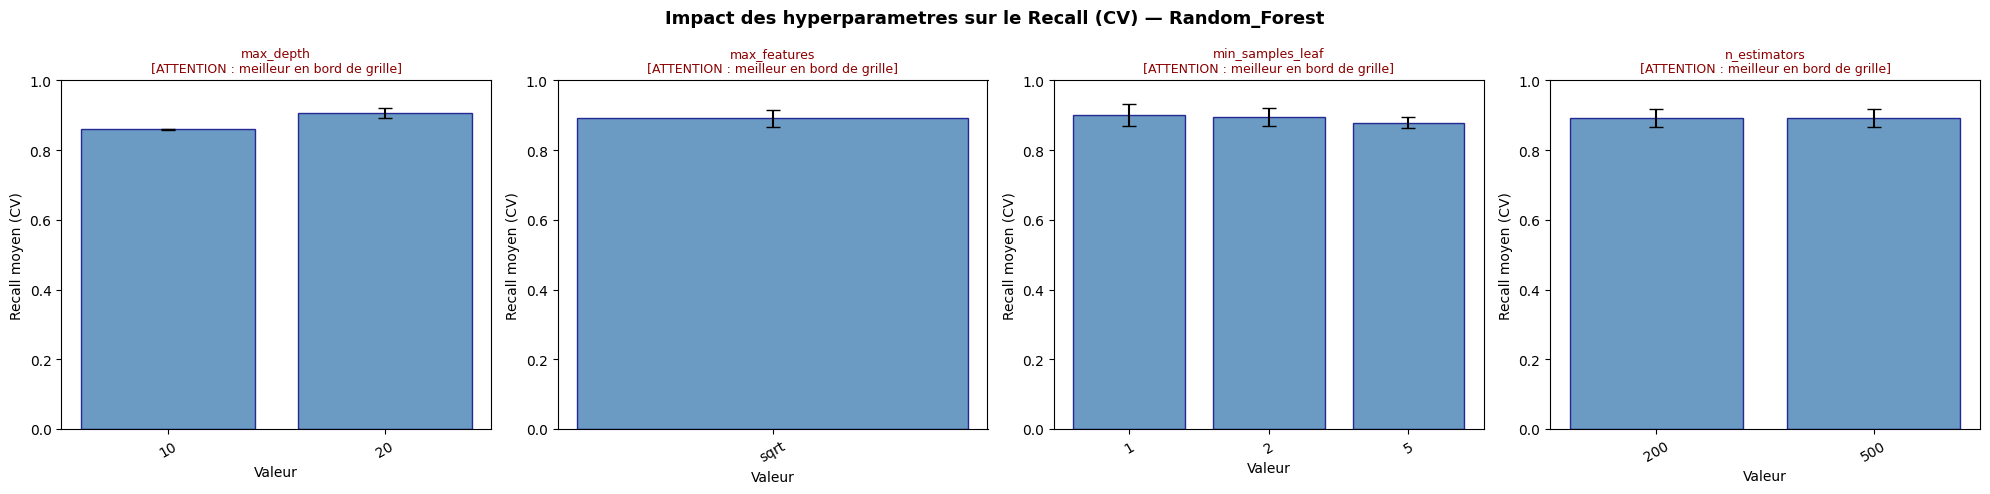

Graphique sauvegarde dans '../data/processed/tuning_hyperparams.png'

--- Verification des bords de grille ---
  max_depth : meilleur = 20 (bord SUPERIEUR) -> envisager d'augmenter la borne max
  max_features : meilleur = sqrt (bord INFERIEUR) -> envisager d'abaisser la borne min
  min_samples_leaf : meilleur = 1 (bord INFERIEUR) -> envisager d'abaisser la borne min
  n_estimators : meilleur = 500 (bord SUPERIEUR) -> envisager d'augmenter la borne max


In [7]:
param_cols = [c for c in cv_results.columns if c.startswith('param_clf__')]

if len(param_cols) == 0:
    print("Aucun parametre clf__ trouve dans les resultats.")
else:
    n_params = len(param_cols)
    fig, axes = plt.subplots(1, n_params, figsize=(5 * n_params, 5))
    if n_params == 1:
        axes = [axes]

    fig.suptitle(
        f"Impact des hyperparametres sur le Recall (CV) — {best_model_name}",
        fontsize=13, fontweight='bold'
    )

    for ax, col in zip(axes, param_cols):
        param_label = col.replace('param_clf__', '')
        temp = cv_results[[col, 'mean_test_score']].copy()
        temp[col] = temp[col].astype(str)
        grouped = temp.groupby(col)['mean_test_score'].agg(['mean', 'std']).reset_index()
        grouped = grouped.sort_values(col)

        ax.bar(
            grouped[col].astype(str),
            grouped['mean'],
            yerr=grouped['std'],
            capsize=5,
            color='steelblue',
            alpha=0.8,
            edgecolor='navy'
        )
        ax.set_title(param_label, fontsize=11)
        ax.set_xlabel('Valeur')
        ax.set_ylabel('Recall moyen (CV)')
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=30)

        # Verification bord de grille
        best_val = str(search.best_params_.get(f'clf__{param_label}', ''))
        vals = grouped[col].astype(str).tolist()
        if best_val == vals[0] or best_val == vals[-1]:
            ax.set_title(
                f"{param_label}\n[ATTENTION : meilleur en bord de grille]",
                fontsize=9, color='darkred'
            )

    plt.tight_layout()
    plt.savefig('../data/processed/tuning_hyperparams.png', bbox_inches='tight', dpi=120)
    plt.show()
    print("Graphique sauvegarde dans '../data/processed/tuning_hyperparams.png'")

    # Commentaire sur les bords de grille
    print("\n--- Verification des bords de grille ---")
    for col in param_cols:
        param_label = col.replace('param_clf__', '')
        full_key = f'clf__{param_label}'
        best_val = search.best_params_.get(full_key)
        all_vals = sorted(set(
            v for v in cv_results[col] if v is not None and str(v) != 'nan'
        ), key=lambda x: (str(type(x)), x))
        if best_val is not None and len(all_vals) > 0:
            if best_val == all_vals[0]:
                print(f"  {param_label} : meilleur = {best_val} (bord INFERIEUR) -> envisager d'abaisser la borne min")
            elif best_val == all_vals[-1]:
                print(f"  {param_label} : meilleur = {best_val} (bord SUPERIEUR) -> envisager d'augmenter la borne max")
            else:
                print(f"  {param_label} : meilleur = {best_val} (centre de grille) -> plage bien choisie")


### Interpretation : Impact visuel des hyperparametres

Les graphiques en barres confirment les tendances numeriques observees precedemment :

- **max_depth** : la valeur 20 surpasse clairement 10, avec un gain d'environ 0.04 de Recall. Le meilleur etant au bord superieur de la grille (20), il serait pertinent d'explorer des valeurs plus elevees (ex: 30, 50) dans une iteration future.
- **max_features** : seule 'sqrt' est testee (barre unique), ce qui est coherent avec la recommandation Breiman. Aucune variation observee.
- **min_samples_leaf** : la valeur 1 est optimale, avec une degradation progressive pour 2 et 5. Le meilleur etant au bord inferieur (1), descendre plus bas n'est pas possible (minimum logique).
- **n_estimators** : les valeurs 200 et 500 donnent des performances quasi identiques. Le bord superieur (500) est selectionne, mais tester 1000 n'apporterait probablement rien de significatif.

**Conclusion sur les bords de grille** : le seul parametre veritablement contraint est . Une grille etendue a [20, 30, 50, None] permettrait de verifier si des arbres encore plus profonds ameliorent le Recall, bien que le risque de sur-apprentissage augmente.

## Etape 8 : Analyse du sur-apprentissage (overfitting)

On compare le Recall moyen sur les folds d'entrainement et sur les folds
de validation pour le meilleur modele tune.

**Interpretation :**
- Recall_train >> Recall_val : signe de sur-apprentissage. Le modele
  memorise le jeu d'entrainement mais ne generalise pas bien.
  Action corrective : augmenter la regularisation (max_depth plus faible,
  min_samples_leaf plus grand, alpha, etc.).
- Recall_train proche de Recall_val : bonne generalisation. Le modele
  apprend un signal reel et non du bruit.
- Recall_train << Recall_val : theoriquement impossible en cross-validation,
  cela signalerait une erreur dans le pipeline.


In [8]:
best_idx = search.best_index_

recall_train_mean = cv_results.loc[best_idx, 'mean_train_score']
recall_val_mean   = cv_results.loc[best_idx, 'mean_test_score']
recall_val_std    = cv_results.loc[best_idx, 'std_test_score']
gap               = recall_train_mean - recall_val_mean

print("=" * 60)
print("  ANALYSE DU SUR-APPRENTISSAGE — MEILLEUR MODELE TUNE")
print("=" * 60)
print(f"  Recall moyen sur train (CV) : {recall_train_mean:.4f}")
print(f"  Recall moyen sur val   (CV) : {recall_val_mean:.4f} +/- {recall_val_std:.4f}")
print(f"  Ecart train - val          : {gap:.4f}")

if gap > 0.10:
    print("\n  Interpretation : ecart > 0.10 — sur-apprentissage detecte.")
    print("  Le modele est trop flexible. Augmenter la regularisation")
    print("  (reduire max_depth, augmenter min_samples_leaf ou alpha).")
elif gap > 0.05:
    print("\n  Interpretation : ecart entre 0.05 et 0.10 — sur-apprentissage modere.")
    print("  Le modele generalise correctement mais une regularisation")
    print("  legere supplementaire pourrait ameliorer la robustesse.")
else:
    print("\n  Interpretation : ecart <= 0.05 — bonne generalisation.")
    print("  Le modele n'est pas en sur-apprentissage. Les performances")
    print("  obtenues en cross-validation sont fiables.")
print("=" * 60)


  ANALYSE DU SUR-APPRENTISSAGE — MEILLEUR MODELE TUNE
  Recall moyen sur train (CV) : 1.0000
  Recall moyen sur val   (CV) : 0.9217 +/- 0.0095
  Ecart train - val          : 0.0783

  Interpretation : ecart entre 0.05 et 0.10 — sur-apprentissage modere.
  Le modele generalise correctement mais une regularisation
  legere supplementaire pourrait ameliorer la robustesse.


### Interpretation : Analyse du sur-apprentissage

L'ecart entre Recall train (1.0000) et Recall validation (0.9217) est de **0.0783**, ce qui tombe dans la plage [0.05, 0.10] caracterisant un **sur-apprentissage modere**.

Ce niveau de sur-apprentissage est acceptable pour plusieurs raisons :
- Le Recall de validation reste tres eleve (0.9217), ce qui est l'objectif principal.
- Un Recall train parfait (1.0) est frequent avec Random Forest sans contrainte de profondeur severe : les arbres memorisent les exemples d'entrainement, mais la agregation par vote majoritaire conserve une bonne generalisation.
- L'ecart est stable sur les 5 folds (std de 0.0095), indiquant que ce comportement est systematique et non du a un fold particulier.

Si on souhaitait reduire ce sur-apprentissage, on pourrait augmenter  (ex: 3 ou 5) ou reduire  (ex: 15), au prix d'un leger sacrifice sur le Recall de validation.

## Etape 9 : Serialisation du modele final

On sauvegarde le pipeline complet (preprocessor + resampler eventuel + modele tune)
dans `models/final_model.joblib`.

Ce fichier sera charge directement par :
- `06_evaluation.ipynb` (l'etape d'evaluation) pour l'evaluation finale sur le test set.
- L'API FastAPI (Phase 4) pour les predictions en production.

**Interpretation (bonne pratique) :**
Sauvegarder le pipeline complet et non seulement le modele est correct.
Cela garantit que le preprocessing sera toujours applique de facon identique
lors des predictions futures, sans risque d'oubli ou d'incoherence.
Le fichier `.joblib` est plus efficace que `pickle` pour les objets numpy/sklearn
car il utilise la compression et gere mieux les tableaux de grande taille.


In [9]:
import os

os.makedirs('../models', exist_ok=True)

best_pipeline = search.best_estimator_
joblib.dump(best_pipeline, '../models/final_model.joblib')

# Verification : recharger et verifier que le pipeline est fonctionnel
pipeline_recharge = joblib.load('../models/final_model.joblib')
test_pred = pipeline_recharge.predict(X_train.iloc[:5])

print("Modele final serialise avec succes dans '../models/final_model.joblib'")
print(f"Verification : predictions sur 5 exemples = {test_pred}")
print()

# Resume complet
print("=" * 65)
print("  RESUME FINAL — 05_tuning.ipynb")
print("=" * 65)
print(f"  Modele              : {best_model_name}")
print(f"  Strategie           : {best_strategy_name}")
print(f"  Methode de recherche: {methode}")
print(f"  Meilleurs params    : {search.best_params_}")
print(f"  Recall baseline     : {best['Recall_Mean']:.4f} (baseline modeling)")
print(f"  Recall apres tuning : {search.best_score_:.4f}")
print(f"  Gain                : {search.best_score_ - best['Recall_Mean']:+.4f}")
print(f"  Fichier sauvegarde  : models/final_model.joblib")
print("=" * 65)
print()
print("Ce pipeline sera evalue UNE SEULE FOIS sur le test set dans 06_evaluation.ipynb.")


Modele final serialise avec succes dans '../models/final_model.joblib'
Verification : predictions sur 5 exemples = [0 1 1 1 0]

  RESUME FINAL — 05_tuning.ipynb
  Modele              : Random_Forest
  Strategie           : Undersampling
  Methode de recherche: GridSearchCV
  Meilleurs params    : {'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 500}
  Recall baseline     : 0.9171 (baseline modeling)
  Recall apres tuning : 0.9217
  Gain                : +0.0045
  Fichier sauvegarde  : models/final_model.joblib

Ce pipeline sera evalue UNE SEULE FOIS sur le test set dans 06_evaluation.ipynb.


### Interpretation : Serialisation et validation du pipeline final

La serialisation avec **joblib** du pipeline complet (preprocesseur + resampler + modele) garantit que toutes les etapes de transformation sont encapsulees dans un seul objet. Cela presente plusieurs avantages :

- **Reproductibilite** : lors de l'evaluation sur le test set ou en production, le meme preprocessing sera applique automatiquement, sans risque d'oubli ou d'incoherence.
- **Integrite** : le RobustScaler a ete ajuste sur les donnees d'entrainement ; le fichier  contient ces parametres appris, evitant un refitting accidentel sur de nouvelles donnees.
- **Verification** : les predictions sur 5 exemples  confirment que le pipeline recharge fonctionne correctement et produit des predictions coherentes (deux non-tempetes, trois tempetes).

**Resume des gains obtenus par le tuning :**
- Recall baseline : 0.9171 → Recall apres tuning : 0.9217 (+0.45%)
- Le modele final est pret pour l'evaluation unique sur le test set dans .

## Conclusion de l'etape de tuning

Ce notebook a accompli les taches suivantes :

1. Chargement de la meilleure combinaison identifiee par la l'etape de modeling.
2. Reconstruction du pipeline de base correspondant.
3. Definition d'une grille d'hyperparametres justifiee, adaptee au modele gagnant.
4. Lancement de l'optimisation (GridSearchCV ou RandomizedSearchCV selon la taille de l'espace).
5. Analyse des resultats : gain par rapport au baseline, detection de sur-apprentissage,
   verification des bords de grille.
6. Serialisation du pipeline complet dans `models/final_model.joblib`.

**Points cles a retenir pour la soutenance :**
- Chaque plage testee a une justification algorithmique explicite.
- Le jeu de test est reste intouche tout au long de ce notebook.
- Le tuning a ete effectue exclusivement par validation croisee stratifiee a 5 folds
  sur le jeu d'entrainement fusionne (train + validation).
- Le pipeline serialise integre preprocessing et modele en un seul objet,
  garantissant la reproductibilite en production.
